# UrbanFusion Tutorial: Coordinate-Only Encoding for Downstream Tasks

This notebook demonstrates how to:

1. **Generate a synthetic dataset** of 32 random (latitude, longitude) points in central London, along with smoothly varying synthetic labels (e.g., mimicking population density).  
2. **Download and apply the pretrained UrbanFusion model** to obtain high-dimensional representations of each location, using only coordinate inputs.  
3. **Leverage these embeddings in a downstream regression task**, where a linear regression model is trained and tuned to predict the synthetic labels, illustrating how UrbanFusion representations can support spatial learning tasks.  




## 0) Setup

Import the required libraries.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", module="sklearn")
warnings.filterwarnings("ignore", category=TqdmWarning)

# UrbanFusion
from huggingface_hub import hf_hub_download
from srl.multi_modal_encoder.load import get_urbanfusion



## 1) Sample 32 Random Locations in London

We'll define a small bounding box roughly around the city center of London and sample 32 random points uniformly in latitude/longitude.

In [2]:
# Reproducibility
rng = np.random.default_rng(42)

# A simple bounding box around central London
# lat_min/max, lon_min/max (WGS84, EPSG:4326)
lat_min, lat_max = 51.495, 51.520
lon_min, lon_max = -0.15, -0.07

# Sample 32 points
n_points = 32
lats = rng.uniform(lat_min, lat_max, n_points)
lons = rng.uniform(lon_min, lon_max, n_points)

# Save in GeoDataFrame
df = pd.DataFrame({'lat': lats, 'lon': lons})
gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['lon'], df['lat'])], crs="EPSG:4326")
gdf.head()


,lat,lon,geometry
0,51.514349,-0.123934,POINT (-0.12393 51.51435)
1,51.505972,-0.120363,POINT (-0.12036 51.50597)
2,51.516465,-0.112436,POINT (-0.11244 51.51646)
3,51.512434,-0.134842,POINT (-0.13484 51.51243)
4,51.497354,-0.139606,POINT (-0.13961 51.49735)


## 2) Create a Synthetic Downstream Task Label

We'll create a smooth field using a **Gaussian (RBF) kernel** over the coordinates. This gives nearby points similar values—i.e., positive spatial autocorrelation.

You can think of this as a toy "population density" target variable.


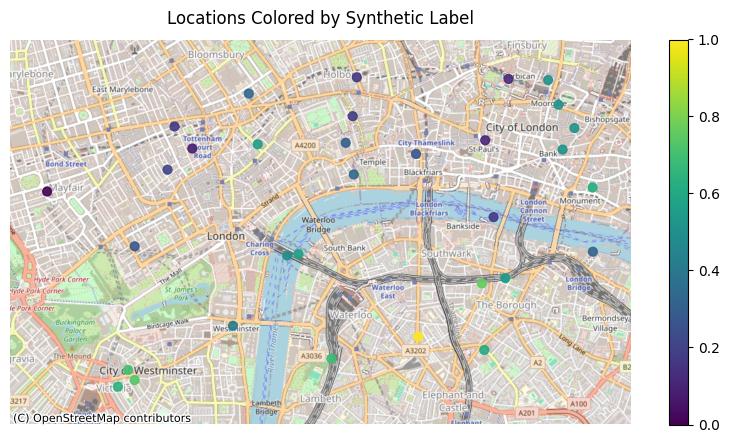

In [ ]:
def rbf_kernel(coords: np.ndarray, length_scale: float=0.01, variance: float=1.0) -> np.ndarray:
    """
    Squared-exponential (RBF) kernel on lat/lon coordinates.
    
    Parameters
    ----------
    coords : np.ndarray
        (n, 2) array of [lat, lon] coordinates.
    length_scale : float
        Length scale parameter for the RBF kernel.
    variance : float
        Variance parameter for the RBF kernel.

    Returns
    -------
    np.ndarray
        (n, n) RBF kernel matrix.
    """
    diffs = coords[:, None, :] - coords[None, :, :]
    dist2 = np.sum(diffs**2, axis=-1)
    return variance * np.exp(-0.5 * dist2 / (length_scale**2))


# Generate synthetic target variables
coords = gdf[['lat','lon']].to_numpy()
K = rbf_kernel(coords, length_scale=0.004, variance=1.0)
K = K + 1e-6 * np.eye(len(coords))
synthetic_field = rng.multivariate_normal(mean=np.zeros(len(coords)), cov=K)
syn_min, syn_max = synthetic_field.min(), synthetic_field.max()
synthetic_norm = (synthetic_field - syn_min) / (syn_max - syn_min + 1e-12)
gdf['synthetic_label'] = synthetic_norm
gdf.head()

# Plot
gdf_3857 = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(10, 5))
gdf_3857.plot(
    ax=ax,
    column='synthetic_label',
    cmap='viridis',
    markersize=40,
    alpha=0.9,
    legend=True
)
buffer_m = 500  # meters
total_bounds = gdf_3857.total_bounds
xmin, ymin, xmax, ymax = total_bounds
xmin, ymin, xmax, ymax = xmin - buffer_m, ymin - buffer_m, xmax + buffer_m, ymax + buffer_m
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Locations Colored by Synthetic Label", pad=12)
plt.show()


## 3) Encode Locations with **UrbanFusion** (Coordinates-Only Setting)

UrbanFusion is a **multimodal encoder** that can integrate several data modalities as input:  
- **Coordinates** (latitude/longitude)  
- **Street-view imagery (SV)**  
- **Remote sensing (RS)**  
- **Cartographic basemaps from OpenStreetMap (OSM)**  
- **Points of interest (POI)**  

The choice of input modalities is **flexible**, depending on data availability and the downstream application.  

In this tutorial, we demonstrate the **coordinates-only setting**, where embeddings are generated solely from geographical coordinates.


In [4]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create tensors of coordinates
coords_tensor = torch.tensor(gdf[['lat','lon']].to_numpy(), dtype=torch.float32, device=device)

# Placeholders for other modalities (SV, RS, OSM, POI)
placeholder = torch.empty(coords_tensor.shape[0], device=device)

# List of all modalities, which are inputs to the model
inputs = [coords_tensor, placeholder, placeholder, placeholder, placeholder]

# Mask all but coordinates (indices: 0=coords, 1=SV, 2=RS, 3=OSM, 4=POI)
mask_indices = [1, 2, 3, 4]

# Load pretrained UrbanFusion model from Hugging Face Hub
ckpt = hf_hub_download("DominikM198/UrbanFusion", "UrbanFusion/UrbanFusion.ckpt")
model = get_urbanfusion(ckpt, device=device).eval()

# Use UrbanFusion model for encoding coordinates
with torch.no_grad():
    embeddings = model(inputs, mask_indices=mask_indices, return_representations=True).detach().cpu().numpy()

print("Embeddings shape:", embeddings.shape)

✅ Checkpoint loaded: C:\Users\domin\.cache\huggingface\hub\models--DominikM198--UrbanFusion\snapshots\23b77424ed36aa776cf3b0158ad9d19adccf7f1a\UrbanFusion\UrbanFusion.ckpt
✅ Weights loaded successfully.
Embeddings shape: (32, 768)


## 4) Qualitative Analysis of UrbanFusion Representations

The code below reduces the embeddings to three principal components using PCA, scales them to the [0, 1] range, and visualizes the results as RGB colors on a map of London.


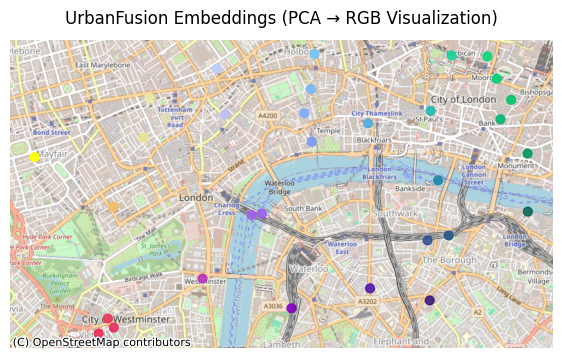

In [5]:
# PCA to 3 components
Z = PCA(n_components=3, random_state=42).fit_transform(embeddings)

# Normalize each comp to 0..1
def to_01(x): 
    a, b = np.percentile(x, [1, 99])
    return np.clip((x - a) / (b - a), 0, 1)

# Assign RGB colors to the three PCA components
rgb = np.stack([to_01(Z[:,0]), to_01(Z[:,1]), to_01(Z[:,2])], axis=1)

# Add colors to gdf and project for basemap
gdf_plot = gdf.to_crs(epsg=3857).copy()
gdf_plot["rgb"] = list(map(tuple, rgb))

# Plot
fig, ax = plt.subplots(figsize=(7,7))
gdf_plot.plot(ax=ax, color=gdf_plot["rgb"], markersize=40, alpha=0.9)
cx.add_basemap(ax, crs=gdf_plot.crs, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("UrbanFusion Embeddings (PCA → RGB Visualization)", pad=12)
plt.show()


## 5) Train and Apply a Downstream Learner for Spatial Regression

Once we have generated location embeddings with UrbanFusion, we can use them as input features for a downstream model (e.g., linear regression, random forest, or an MLP) to predict a target variable at each location.  

The example below demonstrates how to use the UrbanFusion representations to train a **ridge regression model** on the synthetic labels created earlier.


In [6]:
# X: UrbanFusion representations (input features)
X = np.asarray(embeddings)

# y: synthetic labels from earlier step (target variable)
y = gdf['synthetic_label'].to_numpy()

# Train/test split
idx_train, idx_test = train_test_split(np.arange(len(X)), test_size=0.25, random_state=42, shuffle=True)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

# Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Tune alpha via Leave-One-Out CV on the training set
alphas = np.logspace(-4, 4, 25)
best_alpha = RidgeCV(alphas=alphas, cv=LeaveOneOut(), scoring="neg_mean_squared_error").fit(X_train_s, y_train).alpha_

# Train final model
model = Ridge(alpha=best_alpha).fit(X_train_s, y_train)

# Apply model to test set (or new data if model is deployed)
y_pred = model.predict(X_test_s)
rmse = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)

print(f"Best alpha: {best_alpha:.6g}")
print(f"Test RMSE: {rmse:.4f} | MAE: {mae:.4f}")


Best alpha: 100
Test RMSE: 0.0440 | MAE: 0.1465


## 6) Wrap-Up and Next Steps

In this tutorial, we:

- Sampled **32 random locations** in central London.  
- Created a **synthetic spatially autocorrelated label** to mimic a real-world target variable.  
- Generated **coordinate-only embeddings** using the UrbanFusion model.  
- Explored a **qualitative visualization** of the embeddings via PCA and RGB mapping.  
- Applied these embeddings in a **downstream regression task** (ridge regression) to predict the synthetic labels.  

This showed how UrbanFusion representations can support spatial learning tasks even with minimal input (just coordinates).  

For more advanced use cases, see the tutorial **`UrbanFusion_multimodal.ipynb`**, which demonstrates how UrbanFusion can flexibly combine **arbitrary subsets of modalities** (e.g., coordinates, street-view imagery, remote sensing, cartographic basemaps, points of interest) depending on data availability and the downstream application.
